Descargo de responsabilidad:

Esta investigacion es puramente informativa y no constituye asesoramiento financiero. No se recomienda tomar decisiones de inversión basadas únicamente en esta información. Se aconseja realizar un análisis propio y consultar a un profesional financiero antes de tomar decisiones de inversión. Las decisiones de inversión son responsabilidad exclusiva del lector.

En todo momento se incita a hacer un análisis propio, y saber que tus decisiones son completamente tuyas y afectan tus inversiones y tu patrimonio.

● No es una asesoría financiera.

● No supone en ningún caso, esto sea recomendación de inversión, de compra o de venta de ningún activo/bien o subyacente.

● El contenido de la investigacion es meramente informativo.

● En todo momento se incita a hacer un análisis propio, y saber que tus decisiones son completamente tuyas y afectan tus inversiones y tu patrimonio.

In [ ]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime, timedelta
import logging
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass
from concurrent.futures import ThreadPoolExecutor, as_completed
import os
import json

2025-12-04 13:15:12,999 - INFO - Descargando datos para 20 activos...


🚀 Iniciando análisis de portafolio...


[*********************100%***********************]  20 of 20 completed
2025-12-04 13:15:20,784 - INFO - Datos descargados exitosamente. Período: 2015-01-02 a 2025-12-03
2025-12-04 13:15:20,785 - INFO - Activos válidos: ['NVDA', 'MSFT', 'AAPL', 'GOOGL', 'META', 'TSLA', 'AVGO', 'ORCL', 'WMT', 'COST', 'PG', 'KO', 'JPM', 'V', 'MA', 'BRK-B', 'LLY', 'JNJ', 'UNH', 'ABBV']


📊 Ejecutando optimizaciones (SLSQP)...
🔄 Ejecutando backtesting...

REPORTE DE OPTIMIZACIÓN DE PORTAFOLIO (ENFOQUE SOLVER)

PERÍODO: 2015-01-02 a 2025-12-03
CAPITAL: $50,000.00

ESTRATEGIA         RETORNO ESP. VOLATILIDAD  SHARPE  
-------------------------------------------------------
equal_weight            24.7%      18.3%    1.11
max_sharpe              41.3%      25.2%    1.47
min_volatility          13.7%      14.1%    0.66

BACKTESTING (Simulación)  RET.TOTAL  RET.ANUAL  MAX DD  
----------------------------------------------------------------------
equal_weight               1123.1%    25.8%  -29.8%
max_sharpe                 6270.5%    46.4%  -26.6%
min_volatility              298.1%    13.5%  -24.5%

RECOMENDACIÓN: MAX SHARPE (Histórico)
ASIGNACIÓN DE CAPITAL:
------------------------------
LLY   :  33.3% -> $  16,674
NVDA  :  30.7% -> $  15,353
WMT   :  10.7% -> $   5,364
AVGO  :   9.5% -> $   4,762
COST  :   5.9% -> $   2,961
TSLA  :   5.7% -> $   2,846
ABBV  :   4.1% -> $

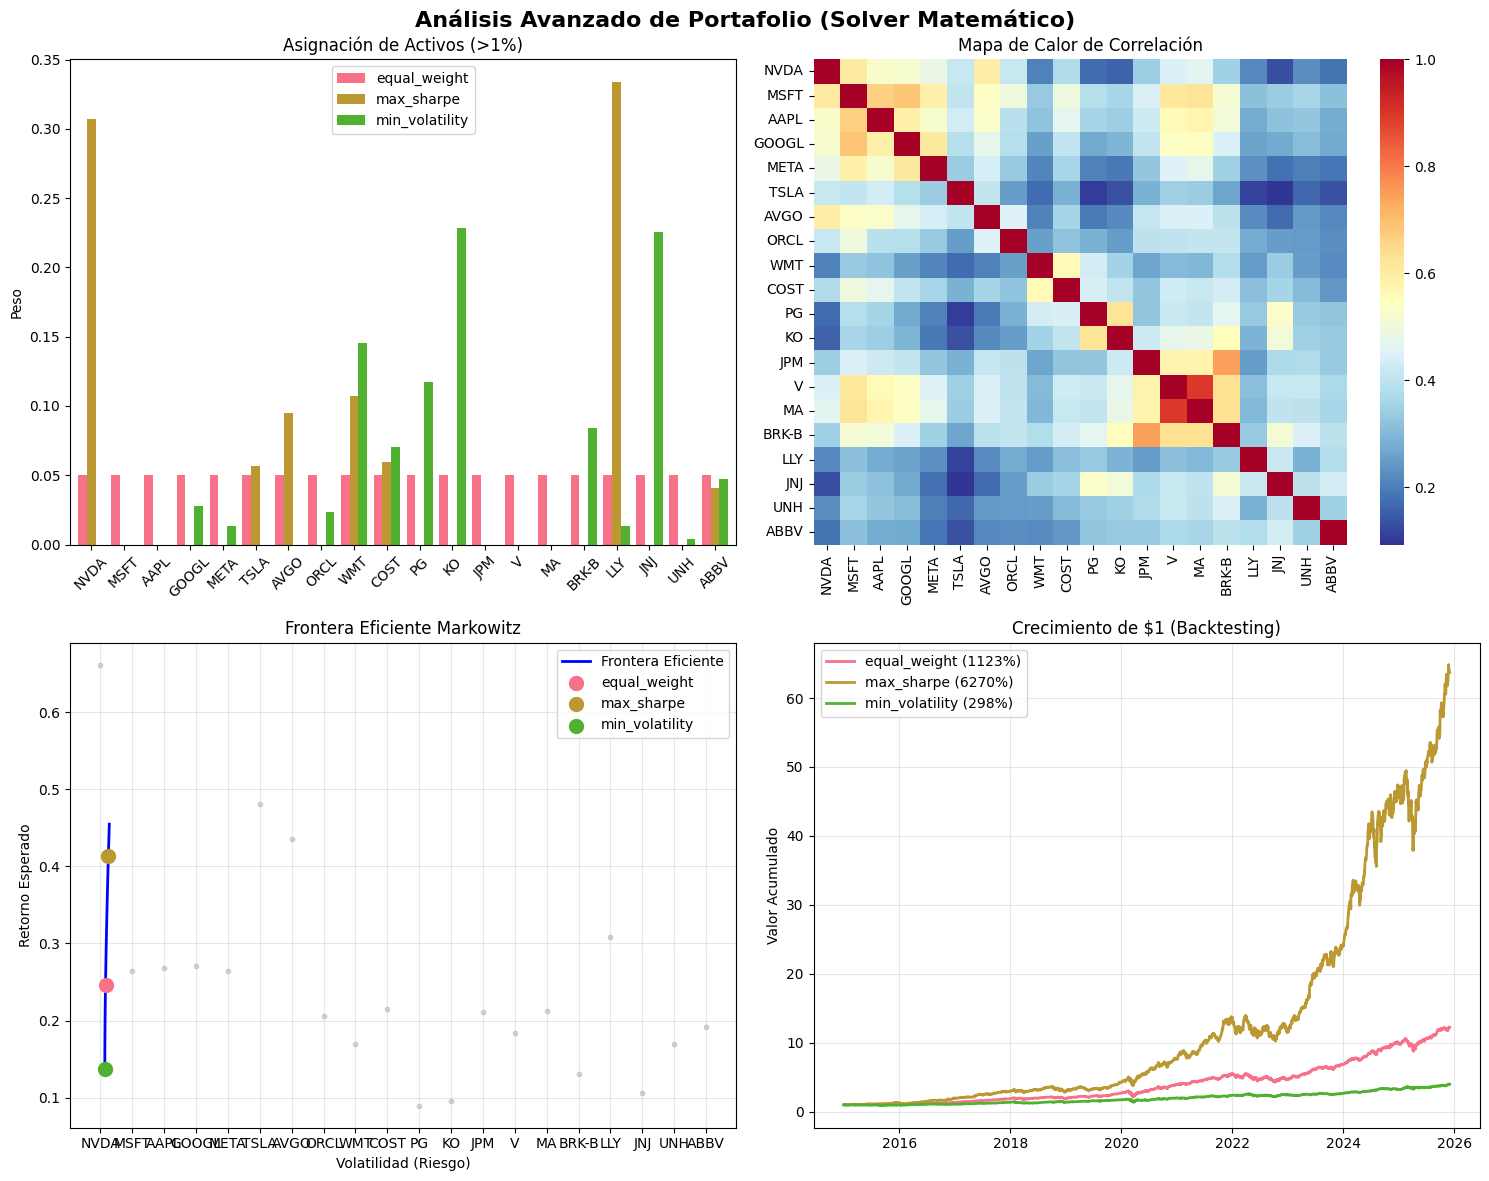


✅ Análisis completado exitosamente!


In [ ]:
# Configuracion de visualizacion y logging
plt.style.use('default')
sns.set_palette("husl")
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

@dataclass
class PortfolioConfig:
    """Configuracion del portafolio con parametros optimizados"""
    tickers: List[str]
    start_date: str = "2015-01-01"
    end_date: Optional[str] = None
    total_value: float = 50000.0
    risk_free_rate: float = 0.04293
    target_return: float = 0.25
    frequency: int = 252
    lookback_years: int = 3

    def __post_init__(self):
        if self.end_date is None:
            self.end_date = datetime.now().strftime("%Y-%m-%d")

class EnhancedPortfolioOptimizer:
    """
    Optimizador avanzado de portafolios usando Scipy (Markowitz Solver)
    """

    def __init__(self, config: PortfolioConfig):
        self.config = config
        self.prices = None
        self.returns = None
        self.cov_matrix = None
        self.expected_returns = None
        self.results = {}

    def download_data(self) -> pd.DataFrame:
        """Descarga datos con manejo robusto de errores y estructura MultiIndex"""
        logging.info(f"Descargando datos para {len(self.config.tickers)} activos...")

        price_data = {}
        failed_tickers = []

        # Descarga
        try:
            data = yf.download(
                self.config.tickers,
                start=self.config.start_date,
                end=self.config.end_date,
                progress=True,
                group_by='ticker',
                auto_adjust=True
            )
        except Exception as e:
            logging.error(f"Error en descarga masiva: {e}")
            return pd.DataFrame()

        for ticker in self.config.tickers:
            try:
                if ticker in data.columns.levels[0]:
                    ticker_data = data[ticker]
                    if 'Close' in ticker_data.columns:
                        close_prices = ticker_data['Close']
                    else:
                        close_prices = ticker_data.iloc[:, 0]
                else:
                    logging.warning(f"Ticker {ticker} no encontrado en descarga masiva, intentando individual...")
                    single_data = yf.download(ticker, start=self.config.start_date, end=self.config.end_date, progress=False, auto_adjust=True)
                    close_prices = single_data['Close']

                close_prices = close_prices.dropna()
                
                if len(close_prices) > 10:
                    price_data[ticker] = close_prices
                else:
                    logging.warning(f"Datos insuficientes para {ticker}")
                    failed_tickers.append(ticker)

            except Exception as e:
                logging.warning(f"Error procesando {ticker}: {e}")
                failed_tickers.append(ticker)

        if not price_data:
            raise ValueError("No se pudieron descargar datos para ningún activo")

        if failed_tickers:
            logging.warning(f"Activos fallidos: {failed_tickers}")

        self.prices = pd.DataFrame(price_data)
        self.prices = self.prices.dropna()
        
        if self.prices.empty:
            raise ValueError("No hay datos validos despues de la limpieza (interseccion vacia)")

        self.returns = self.prices.pct_change().dropna()

        logging.info(f"Datos descargados exitosamente. Periodo: {self.prices.index[0].date()} a {self.prices.index[-1].date()}")
        logging.info(f"Activos validos: {list(self.prices.columns)}")
        return self.prices

    def calculate_basic_metrics(self):
        """Calcula metricas basicas de riesgo y retorno (Modelo Historico)"""
        if self.prices is None or self.returns is None:
            raise ValueError("Primero debe descargar los datos")

        # Retornos esperados anualizados (Promedio Historico)
        mean_returns = self.returns.mean() * self.config.frequency
        
        # Matriz de covarianza anualizada
        cov_matrix = self.returns.cov() * self.config.frequency
        
        # Volatilidades anualizadas
        volatilities = self.returns.std() * np.sqrt(self.config.frequency)
        
        self.expected_returns = mean_returns
        self.cov_matrix = cov_matrix
        
        return {
            'expected_returns': mean_returns,
            'covariance_matrix': cov_matrix,
            'volatilities': volatilities
        }

    def optimize_equal_weight(self) -> Dict:
        """Estrategia de pesos iguales (benchmark)"""
        n_assets = len(self.prices.columns)
        weights = pd.Series(1.0/n_assets, index=self.prices.columns)
        
        portfolio_return = np.dot(weights, self.expected_returns)
        portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(self.cov_matrix, weights)))
        sharpe_ratio = (portfolio_return - self.config.risk_free_rate) / portfolio_volatility
        
        result = {
            'weights': weights.to_dict(),
            'performance': {
                'expected_return': portfolio_return,
                'volatility': portfolio_volatility,
                'sharpe_ratio': sharpe_ratio
            }
        }
        
        self.results['equal_weight'] = result
        return result

    def optimize_max_sharpe(self) -> Dict:
        """Optimizacion para maximo ratio de Sharpe usando Scipy"""
        from scipy.optimize import minimize
        
        n_assets = len(self.expected_returns)
        
        def negative_sharpe(weights):
            portfolio_return = np.dot(weights, self.expected_returns)
            portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(self.cov_matrix, weights)))
            if portfolio_volatility == 0:
                return 0
            return -(portfolio_return - self.config.risk_free_rate) / portfolio_volatility
        
        # Restricciones: Suma de pesos = 1
        constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
        # Limites: 0 <= peso <= 1 (No short selling)
        bounds = tuple((0, 1) for _ in range(n_assets))
        
        # Punto inicial (pesos iguales)
        x0 = np.array([1.0/n_assets] * n_assets)
        
        # Optimizacion
        result = minimize(negative_sharpe, x0, method='SLSQP', bounds=bounds, constraints=constraints)
        
        if result.success:
            optimal_weights = pd.Series(result.x, index=self.expected_returns.index)
            
            # Limpiar pesos muy pequeños (ruido numerico)
            optimal_weights[optimal_weights < 0.0001] = 0
            optimal_weights = optimal_weights / optimal_weights.sum()
            
            portfolio_return = np.dot(optimal_weights, self.expected_returns)
            portfolio_volatility = np.sqrt(np.dot(optimal_weights.T, np.dot(self.cov_matrix, optimal_weights)))
            sharpe_ratio = (portfolio_return - self.config.risk_free_rate) / portfolio_volatility
            
            optimization_result = {
                'weights': optimal_weights.to_dict(),
                'performance': {
                    'expected_return': portfolio_return,
                    'volatility': portfolio_volatility,
                    'sharpe_ratio': sharpe_ratio
                }
            }
            
            self.results['max_sharpe'] = optimization_result
            return optimization_result
        else:
            logging.error("La optimizacion de maximo Sharpe fallo")
            return {}

    def optimize_min_volatility(self) -> Dict:
        """Optimizacion para minima volatilidad"""
        from scipy.optimize import minimize
        
        n_assets = len(self.expected_returns)
        
        def portfolio_volatility(weights):
            return np.sqrt(np.dot(weights.T, np.dot(self.cov_matrix, weights)))
        
        constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
        bounds = tuple((0, 1) for _ in range(n_assets))
        x0 = np.array([1.0/n_assets] * n_assets)
        
        result = minimize(portfolio_volatility, x0, method='SLSQP', bounds=bounds, constraints=constraints)
        
        if result.success:
            optimal_weights = pd.Series(result.x, index=self.expected_returns.index)
            optimal_weights[optimal_weights < 0.0001] = 0
            optimal_weights = optimal_weights / optimal_weights.sum()
            
            portfolio_return = np.dot(optimal_weights, self.expected_returns)
            portfolio_volatility = np.sqrt(np.dot(optimal_weights.T, np.dot(self.cov_matrix, optimal_weights)))
            sharpe_ratio = (portfolio_return - self.config.risk_free_rate) / portfolio_volatility
            
            optimization_result = {
                'weights': optimal_weights.to_dict(),
                'performance': {
                    'expected_return': portfolio_return,
                    'volatility': portfolio_volatility,
                    'sharpe_ratio': sharpe_ratio
                }
            }
            
            self.results['min_volatility'] = optimization_result
            return optimization_result
        else:
            logging.error("La optimizacion de minima volatilidad fallo")
            return {}

    def calculate_efficient_frontier(self, num_portfolios=50):
        """Calcula la frontera eficiente"""
        from scipy.optimize import minimize

        min_ret = self.results['min_volatility']['performance']['expected_return']
        max_ret = self.results['max_sharpe']['performance']['expected_return']
        
        target_returns = np.linspace(min_ret, max_ret * 1.1, num_portfolios)
        
        efficient_portfolios = []
        n_assets = len(self.expected_returns)
        
        for target_return in target_returns:
            def portfolio_volatility(weights):
                return np.sqrt(np.dot(weights.T, np.dot(self.cov_matrix, weights)))
            
            constraints = [
                {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
                {'type': 'eq', 'fun': lambda x: np.dot(x, self.expected_returns) - target_return}
            ]
            bounds = tuple((0, 1) for _ in range(n_assets))
            x0 = np.array([1.0/n_assets] * n_assets)
            
            result = minimize(portfolio_volatility, x0, method='SLSQP', bounds=bounds, constraints=constraints)
            
            if result.success:
                efficient_portfolios.append({
                    'return': target_return,
                    'volatility': result.fun,
                    'weights': result.x
                })
        
        return efficient_portfolios

    def backtest_strategies(self, start_date: str = "2015-01-01") -> Dict:
        """
        Backtesting basico de estrategias.
        NOTA: Esto utiliza los pesos optimizados en todo el periodo y los aplica al pasado.
        Tiene sesgo de anticipacion (Look-ahead bias), pero sirve para ver el potencial maximo.
        """
        if not self.results:
            return {}

        # Filtrar datos para backtesting
        backtest_start = pd.to_datetime(start_date)
        backtest_prices = self.prices[self.prices.index >= backtest_start]
        
        if backtest_prices.empty:
            return {}

        backtest_results = {}
        backtest_returns = backtest_prices.pct_change().fillna(0) # fillna 0 para el primer dia

        for strategy_name, strategy_data in self.results.items():
            if 'weights' not in strategy_data:
                continue

            try:
                weights = pd.Series(strategy_data['weights'])
                
                # Calcular retornos diarios del portafolio
                portfolio_returns = (backtest_returns[weights.index] * weights).sum(axis=1)
                
                # Calcular metricas acumuladas
                cumulative = (1 + portfolio_returns).cumprod()
                total_return = cumulative.iloc[-1] - 1
                
                # Metricas anualizadas
                days = len(portfolio_returns)
                annualized_return = (1 + total_return) ** (252 / days) - 1
                volatility = portfolio_returns.std() * np.sqrt(252)
                sharpe = (annualized_return - self.config.risk_free_rate) / volatility if volatility != 0 else 0
                
                # Drawdown
                running_max = cumulative.cummax()
                drawdown = (cumulative - running_max) / running_max
                max_drawdown = drawdown.min()
                
                backtest_results[strategy_name] = {
                    'returns': portfolio_returns,
                    'cumulative_returns': cumulative,
                    'metrics': {
                        'total_return': total_return,
                        'annualized_return': annualized_return,
                        'volatility': volatility,
                        'sharpe_ratio': sharpe,
                        'max_drawdown': max_drawdown
                    }
                }

            except Exception as e:
                logging.error(f"Error en backtesting para {strategy_name}: {e}")

        self.results['backtesting'] = backtest_results
        return backtest_results

    def create_visualizations(self):
        """Crea visualizaciones del analisis"""
        if not self.results:
            logging.warning("No hay resultados para visualizar")
            return

        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle('Analisis Avanzado de Portafolio (Solver Matematico)', fontsize=16, fontweight='bold')

        # 1. Comparacion de pesos
        ax1 = axes[0, 0]
        strategies_weights = {}
        for strategy, data in self.results.items():
            if 'weights' in data and strategy != 'backtesting':
                # Filtrar solo pesos > 1% para limpiar el grafico
                weights = pd.Series(data['weights'])
                strategies_weights[strategy] = weights
        
        if strategies_weights:
            weights_df = pd.DataFrame(strategies_weights).fillna(0)
            # Mostrar solo activos con peso relevante en alguna estrategia
            relevant_assets = weights_df.index[weights_df.max(axis=1) > 0.01]
            weights_df.loc[relevant_assets].plot(kind='bar', ax=ax1, width=0.8)
            ax1.set_title('Asignacion de Activos (>1%)')
            ax1.set_ylabel('Peso')
            ax1.legend()
            ax1.tick_params(axis='x', rotation=45)

        # 2. Matriz de correlacion
        ax2 = axes[0, 1]
        correlation_matrix = self.returns.corr()
        sns.heatmap(correlation_matrix, annot=False, cmap='RdYlBu_r', ax=ax2)
        ax2.set_title('Mapa de Calor de Correlacion')

        # 3. Frontera eficiente
        ax3 = axes[1, 0]
        if len(self.expected_returns) > 1:
            try:
                efficient_portfolios = self.calculate_efficient_frontier(50)
                if efficient_portfolios:
                    returns = [p['return'] for p in efficient_portfolios]
                    volatilities = [p['volatility'] for p in efficient_portfolios]
                    ax3.plot(volatilities, returns, 'b-', linewidth=2, label='Frontera Eficiente')
                    
                    # Agregar puntos de estrategias optimizadas
                    for strategy, data in self.results.items():
                        if 'performance' in data and strategy != 'backtesting':
                            perf = data['performance']
                            ax3.scatter(perf['volatility'], perf['expected_return'], 
                                      s=100, label=strategy, zorder=5)
                    
                    # Agregar activos individuales
                    ax3.scatter(self.results['equal_weight']['weights'].keys(), 
                              self.expected_returns, color='gray', alpha=0.3, s=10)

                    ax3.set_xlabel('Volatilidad (Riesgo)')
                    ax3.set_ylabel('Retorno Esperado')
                    ax3.set_title('Frontera Eficiente Markowitz')
                    ax3.legend()
                    ax3.grid(True, alpha=0.3)
            except Exception as e:
                ax3.text(0.5, 0.5, f'Error calculando frontera: {e}', 
                        transform=ax3.transAxes, ha='center')

        # 4. Performance de backtesting
        ax4 = axes[1, 1]
        if 'backtesting' in self.results:
            for strategy, data in self.results['backtesting'].items():
                cumulative_returns = data['cumulative_returns']
                ax4.plot(cumulative_returns.index, cumulative_returns.values, 
                        label=f"{strategy} ({data['metrics']['total_return']:.0%})", linewidth=2)
            
            ax4.set_title('Crecimiento de $1 (Backtesting)')
            ax4.set_ylabel('Valor Acumulado')
            ax4.legend()
            ax4.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def generate_report(self):
        """Genera reporte de resultados"""
        print("\n" + "="*60)
        print("REPORTE DE OPTIMIZACIoN DE PORTAFOLIO (ENFOQUE SOLVER)")
        print("="*60)
        
        print(f"\nPERiODO: {self.prices.index[0].date()} a {self.prices.index[-1].date()}")
        print(f"CAPITAL: ${self.config.total_value:,.2f}")
        
        # Resumen de estrategias
        print(f"\n{'ESTRATEGIA':<18} {'RETORNO ESP.':<12} {'VOLATILIDAD':<12} {'SHARPE':<8}")
        print("-" * 55)
        
        for strategy, data in self.results.items():
            if 'performance' in data and strategy != 'backtesting':
                perf = data['performance']
                print(f"{strategy:<18} {perf['expected_return']:>10.1%} {perf['volatility']:>10.1%} {perf['sharpe_ratio']:>7.2f}")
        
        # Backtesting results
        if 'backtesting' in self.results:
            print(f"\n{'BACKTESTING (Simulacion)':<25} {'RET.TOTAL':<10} {'RET.ANUAL':<10} {'MAX DD':<8}")
            print("-" * 70)
            
            for strategy, data in self.results['backtesting'].items():
                metrics = data['metrics']
                print(f"{strategy:<25} {metrics['total_return']:>8.1%} {metrics['annualized_return']:>8.1%} {metrics['max_drawdown']:>7.1%}")

        # Asignacion de capital para Max Sharpe
        if 'max_sharpe' in self.results:
            print(f"\nRECOMENDACIoN: MAX SHARPE (Historico)")
            print("ASIGNACIoN DE CAPITAL:")
            print("-" * 30)
            
            weights = self.results['max_sharpe']['weights']
            # Ordenar por peso
            sorted_weights = dict(sorted(weights.items(), key=lambda item: item[1], reverse=True))
            
            for asset, weight in sorted_weights.items():
                if weight > 0.01:  # Solo mostrar weights > 1%
                    allocation = weight * self.config.total_value
                    print(f"{asset:<6}: {weight:>6.1%} -> ${allocation:>8,.0f}")

def main():
    """Funcion principal"""
    
    # Configuracion del portafolio
    config = PortfolioConfig(
        tickers=[
            'NVDA', 'MSFT', 'AAPL', 'GOOGL', 'META', 'TSLA', 'AVGO', 'ORCL',
            'WMT', 'COST', 'PG', 'KO',
            'JPM', 'V', 'MA', 'BRK-B',
            'LLY', 'JNJ', 'UNH', 'ABBV'
        ],
        start_date="2015-01-01",
        total_value=50000.0
    )

    # Crear optimizador
    optimizer = EnhancedPortfolioOptimizer(config)

    try:
        print("🚀 Iniciando analisis de portafolio...")

        # 1. Descargar datos
        optimizer.download_data()

        # 2. Calcular metricas basicas
        optimizer.calculate_basic_metrics()

        # 3. Ejecutar optimizaciones matematicas (Solver)
        print("📊 Ejecutando optimizaciones (SLSQP)...")
        optimizer.optimize_equal_weight()
        optimizer.optimize_max_sharpe()
        optimizer.optimize_min_volatility()

        # 4. Backtesting
        print("🔄 Ejecutando backtesting...")
        optimizer.backtest_strategies()

        # 5. Generar reporte
        optimizer.generate_report()
        
        # 6. Crear visualizaciones
        print("📈 Generando graficos...")
        optimizer.create_visualizations()

        print("\n✅ Analisis completado exitosamente!")

    except Exception as e:
        logging.error(f"Error en ejecucion principal: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()